In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 1. Read the detrended CO field

In [2]:
ds = xr.open_dataset("detr_field.nc")
ds

<xarray.Dataset> Size: 5MB
Dimensions:                        (time: 276, lat: 36, lon: 61)
Coordinates:
  * time                           (time) datetime64[ns] 2kB 2003-01-01 ... 2...
  * lat                            (lat) float32 144B 14.5 15.5 ... 48.5 49.5
  * lon                            (lon) float32 244B -126.5 -125.5 ... -66.5
Data variables:
    __xarray_dataarray_variable__  (time, lat, lon) float64 5MB ...

In [3]:
detr = ds["__xarray_dataarray_variable__"]
detr = detr.rename("co_detrended")
print(detr)

<xarray.DataArray 'co_detrended' (time: 276, lat: 36, lon: 61)> Size: 5MB
[606096 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2025-12-01
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5


In [4]:
print("time range :", str(detr.time.values[0])[:10], "to", str(detr.time.values[-1])[:10])
print("lat range  :", float(detr.lat.min()), "to", float(detr.lat.max()))
print("lon range  :", float(detr.lon.min()), "to", float(detr.lon.max()))
print("min / max  :", float(detr.min()), "/", float(detr.max()))
print("mean       :", float(detr.mean()))

time range : 2003-01-01 to 2025-12-01
lat range  : 14.5 to 49.5
lon range  : -126.5 to -66.5
min / max  : -2.968342862295363e-08 / 6.809900637206061e-08
mean       : -6.220286404578957e-24


## 2. Standard deviation map

In [5]:
std_map = detr.std(dim="time")
print(std_map)

<xarray.DataArray 'co_detrended' (lat: 36, lon: 61)> Size: 18kB
array([[5.03575134e-09, 5.00324896e-09, 4.86421003e-09, ...,
        5.69286294e-09, 5.66742217e-09, 5.66307728e-09],
       [5.52722038e-09, 5.45519709e-09, 5.30749711e-09, ...,
        5.65754969e-09, 5.64855620e-09, 5.68075633e-09],
       [6.06295556e-09, 5.90118582e-09, 5.73922409e-09, ...,
        5.64723781e-09, 5.72065929e-09, 5.71981416e-09],
       ...,
       [9.83500249e-09, 9.95658340e-09, 9.89185694e-09, ...,
        8.58116826e-09, 8.43328228e-09, 8.26876183e-09],
       [1.00581956e-08, 1.01027672e-08, 9.81356229e-09, ...,
        8.29519741e-09, 8.46432615e-09, 8.51230357e-09],
       [9.84053486e-09, 9.68768333e-09, 1.00973513e-08, ...,
        8.69497508e-09, 8.28205171e-09, 7.92972979e-09]])
Coordinates:
  * lat      (lat) float32 144B 14.5 15.5 16.5 17.5 18.5 ... 46.5 47.5 48.5 49.5
  * lon      (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5


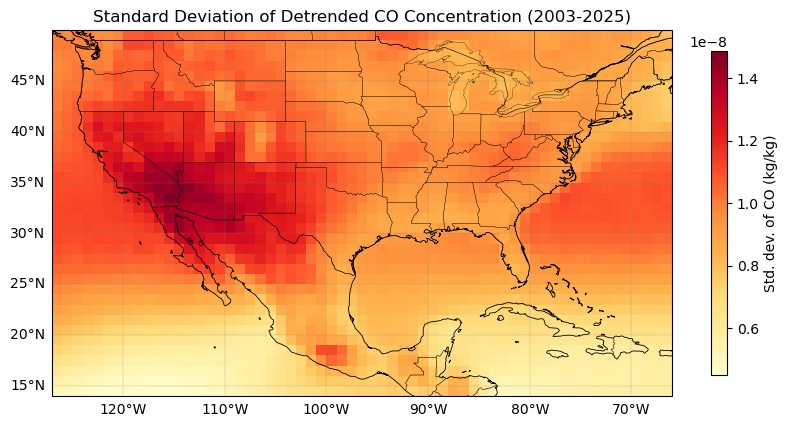

In [6]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
p = ax.pcolormesh(std_map.lon, std_map.lat, std_map,
                  cmap="YlOrRd", shading="auto",
                  transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.STATES, linewidth=0.2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(p, ax=ax, orientation="vertical", shrink=0.7,
             label="Std. dev. of CO (kg/kg)")
ax.set_title("Standard Deviation of Detrended CO Concentration (2003-2025)")
plt.show()

## 3. Residuals = detrended field - periodicities

In [7]:
ds_per = xr.open_dataset("periodicities.nc")
ds_per

<xarray.Dataset> Size: 24MB
Dimensions:        (time: 276, lat: 36, lon: 61)
Coordinates:
  * time           (time) datetime64[ns] 2kB 2003-01-01 ... 2025-12-01
  * lat            (lat) float32 144B 14.5 15.5 16.5 17.5 ... 47.5 48.5 49.5
  * lon            (lon) float32 244B -126.5 -125.5 -124.5 ... -68.5 -67.5 -66.5
Data variables:
    periodicities  (time, lat, lon) float64 5MB ...
    harmonic_12m   (time, lat, lon) float64 5MB ...
    harmonic_6m    (time, lat, lon) float64 5MB ...
    harmonic_4m    (time, lat, lon) float64 5MB ...
    residual       (time, lat, lon) float64 5MB ...
Attributes:
    title:                             AIRS CO mid-troposphere — combined har...
    source:                            detr_field.nc, least-squares harmonic ...
    time_coverage:                     2003-01-01 to 2025-12-01
    variance_explained_total_percent:  71.254875256853
    variance_explained_12m_percent:    57.47062277944063
    variance_explained_6m_percent:     10.634302074787994
    variance_explained_4m_percent:     3.1499504026243788

In [8]:
per = ds_per["periodicities"]
residual = detr - per
print(residual)

<xarray.DataArray (time: 276, lat: 36, lon: 61)> Size: 5MB
array([[[ 4.16628307e-09,  4.06422068e-09,  4.20856470e-09, ...,
          2.24303579e-09,  2.63372065e-09,  2.74292426e-09],
        [ 4.38820687e-09,  4.20504460e-09,  4.49374237e-09, ...,
          1.71906381e-09,  1.98751532e-09,  2.56966933e-09],
        [ 4.92777613e-09,  4.70005634e-09,  4.77433369e-09, ...,
          1.40095891e-09,  1.84647805e-09,  2.13349001e-09],
        ...,
        [ 3.14355094e-10,  2.76407644e-10,  2.01477130e-09, ...,
          1.36655218e-09,  1.11920079e-09,  1.72113928e-09],
        [-4.76790591e-10, -1.67281295e-10, -1.33157220e-10, ...,
          2.18446429e-09,  2.13557703e-09,  2.50732277e-09],
        [ 1.97392069e-11, -5.51901925e-10, -9.65304179e-11, ...,
          2.43566464e-09,  4.93175807e-09,  6.55246173e-09]],

       [[ 5.08738534e-10,  9.97508159e-10,  6.73964697e-10, ...,
         -2.28042439e-10, -4.46833462e-10, -5.60333952e-10],
        [ 1.01303038e-09,  4.77237072e-10,  

In [9]:
res_mean_map = residual.mean(dim="time")
vmax = float(abs(res_mean_map).max())
print("colorbar limits: -", vmax, "to +", vmax)

colorbar limits: - 1.9501682050299097e-23 to + 1.9501682050299097e-23


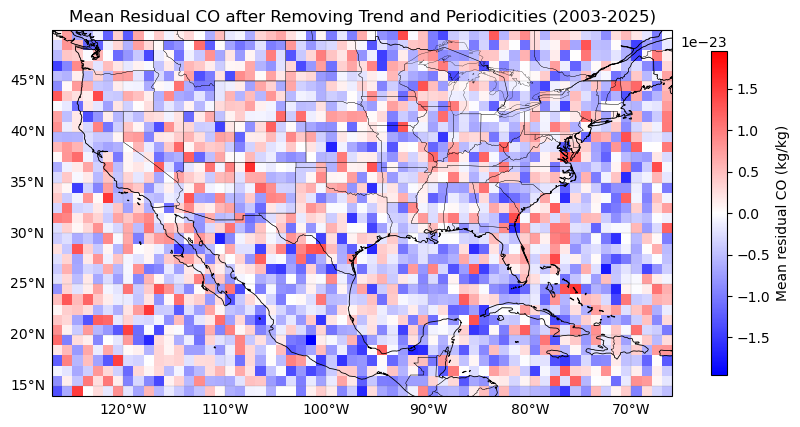

In [10]:
fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
p = ax.pcolormesh(res_mean_map.lon, res_mean_map.lat, res_mean_map,
                  cmap="bwr", vmin=-vmax, vmax=vmax, shading="auto",
                  transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.STATES, linewidth=0.2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(p, ax=ax, orientation="vertical", shrink=0.7,
             label="Mean residual CO (kg/kg)")
ax.set_title("Mean Residual CO after Removing Trend and Periodicities (2003-2025)")
plt.show()

The mean residual map above is essentially zero everywhere (~1e-23, i.e. floating point noise).
That is expected: the harmonics are fitted per pixel by least squares, so the residual has
zero time mean at every grid point by construction. The standard deviation of the residual
below is the informative map - it shows where the harmonic fit leaves the most unexplained
variability.

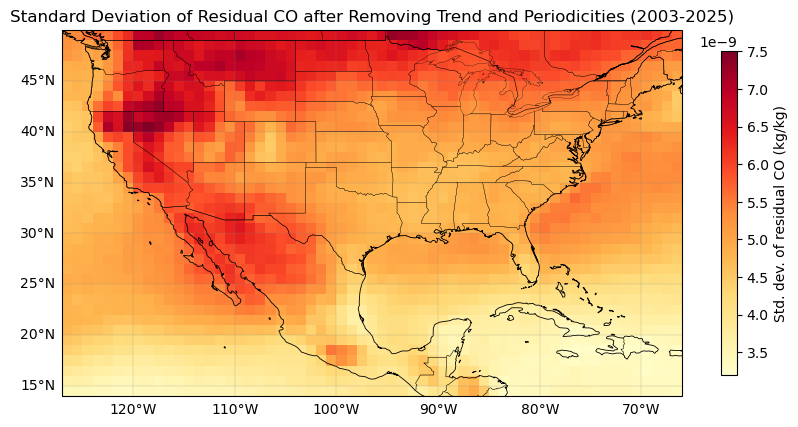

In [11]:
res_std_map = residual.std(dim="time")

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
p = ax.pcolormesh(res_std_map.lon, res_std_map.lat, res_std_map,
                  cmap="YlOrRd", shading="auto",
                  transform=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.add_feature(cfeature.STATES, linewidth=0.2)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False
plt.colorbar(p, ax=ax, orientation="vertical", shrink=0.7,
             label="Std. dev. of residual CO (kg/kg)")
ax.set_title("Standard Deviation of Residual CO after Removing Trend and Periodicities (2003-2025)")
plt.show()

## Helper for the time series plots (used in 4, 5 and 6)

In [12]:
def plot_timeseries(ts, title, ylabel, color):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ts.time, ts, color=color, linewidth=1.0)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 4. Domain mean time series of the detrended field

In [13]:
ts_detr = detr.mean(dim=["lat", "lon"])
print(ts_detr)

<xarray.DataArray 'co_detrended' (time: 276)> Size: 2kB
array([ 2.41185659e-09,  3.48357680e-09,  1.01461818e-08,  1.95045218e-08,
        1.53907223e-08,  7.92780886e-09, -5.05321272e-09, -8.81018199e-09,
       -7.10785800e-09, -7.06197817e-09, -5.29485566e-09, -3.66497016e-09,
        5.26360504e-10,  5.98712127e-09,  1.17623666e-08,  2.27133537e-08,
        7.64374104e-09, -4.65045329e-09, -7.97293050e-09, -1.13944429e-08,
       -1.20221357e-08, -1.17185767e-08, -6.56182845e-09, -3.94674629e-09,
        1.40456504e-09,  9.91285019e-09,  2.00846837e-08,  2.16663668e-08,
        1.57336411e-08, -1.36063440e-09, -8.73292384e-09, -1.12561501e-08,
       -1.21476668e-08, -8.18003008e-09, -5.03294774e-09, -6.66382042e-10,
        2.72576930e-09,  1.27551272e-09,  8.25412615e-09,  1.31690327e-08,
        9.08087558e-09, -2.19191644e-10, -6.83398478e-09, -1.03564068e-08,
       -9.42500564e-09, -8.55736267e-09, -3.07972037e-09, -1.37325903e-10,
        1.81555909e-09,  8.46430821e-09,  1.

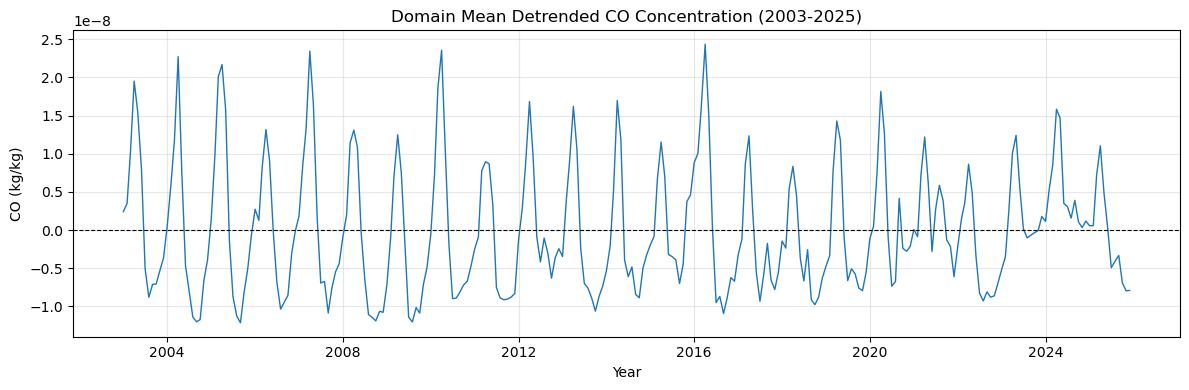

In [14]:
plot_timeseries(ts_detr,
                "Domain Mean Detrended CO Concentration (2003-2025)",
                "CO (kg/kg)",
                "tab:blue")

## 5. Domain mean time series of the periodicities

In [15]:
ts_per = per.mean(dim=["lat", "lon"])
print(ts_per)

<xarray.DataArray 'periodicities' (time: 276)> Size: 2kB
array([-1.55182701e-09,  2.03367739e-09,  9.75846877e-09,  1.49421533e-08,
        1.01047171e-08, -3.79025573e-10, -6.27574052e-09, -6.21894655e-09,
       -6.11617040e-09, -7.11458580e-09, -5.91944789e-09, -3.26327279e-09,
       -1.55182701e-09,  2.03367739e-09,  9.75846877e-09,  1.49421533e-08,
        1.01047171e-08, -3.79025573e-10, -6.27574052e-09, -6.21894655e-09,
       -6.11617040e-09, -7.11458580e-09, -5.91944789e-09, -3.26327279e-09,
       -1.55182701e-09,  2.03367739e-09,  9.75846877e-09,  1.49421533e-08,
        1.01047171e-08, -3.79025573e-10, -6.27574052e-09, -6.21894655e-09,
       -6.11617040e-09, -7.11458580e-09, -5.91944789e-09, -3.26327279e-09,
       -1.55182701e-09,  2.03367739e-09,  9.75846877e-09,  1.49421533e-08,
        1.01047171e-08, -3.79025573e-10, -6.27574052e-09, -6.21894655e-09,
       -6.11617040e-09, -7.11458580e-09, -5.91944789e-09, -3.26327279e-09,
       -1.55182701e-09,  2.03367739e-09,  9

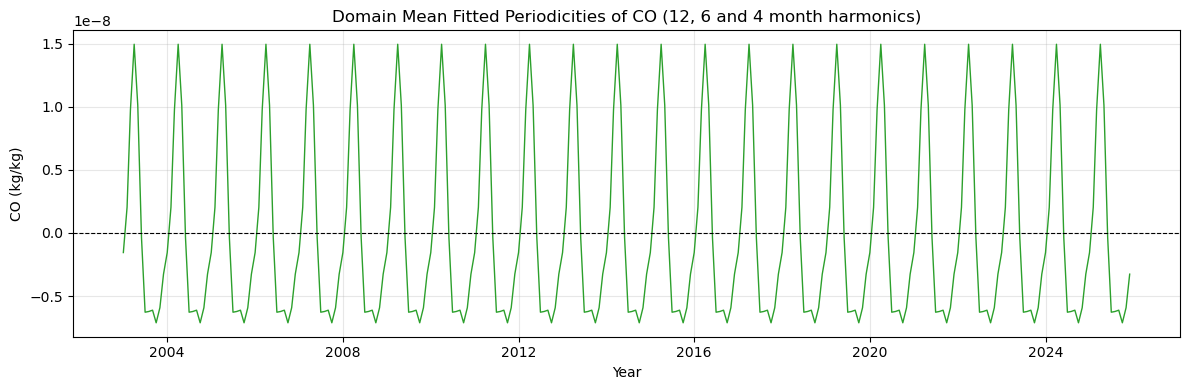

In [16]:
plot_timeseries(ts_per,
                "Domain Mean Fitted Periodicities of CO (12, 6 and 4 month harmonics)",
                "CO (kg/kg)",
                "tab:green")

## 6. Mean anomaly time series = (4) - (5)

In [17]:
ts_anom = ts_detr - ts_per
print(ts_anom)

<xarray.DataArray (time: 276)> Size: 2kB
array([ 3.96368360e-09,  1.44989941e-09,  3.87713058e-10,  4.56236849e-09,
        5.28600522e-09,  8.30683443e-09,  1.22252781e-09, -2.59123544e-09,
       -9.91687596e-10,  5.26076304e-11,  6.24592231e-10, -4.01697365e-10,
        2.07818752e-09,  3.95344389e-09,  2.00389786e-09,  7.77120040e-09,
       -2.46097602e-09, -4.27142771e-09, -1.69718998e-09, -5.17549630e-09,
       -5.90596534e-09, -4.60399090e-09, -6.42380558e-10, -6.83473501e-10,
        2.95639205e-09,  7.87917281e-09,  1.03262150e-08,  6.72421345e-09,
        5.62892399e-09, -9.81608830e-10, -2.45718332e-09, -5.03720353e-09,
       -6.03149638e-09, -1.06544428e-09,  8.86500153e-10,  2.59689075e-09,
        4.27759631e-09, -7.58164665e-10, -1.50434262e-09, -1.77312061e-09,
       -1.02384148e-09,  1.59833929e-10, -5.58244255e-10, -4.13746020e-09,
       -3.30883524e-09, -1.44277687e-09,  2.83972752e-09,  3.12594689e-09,
        3.36738610e-09,  6.43063082e-09,  3.49407695e-09,  

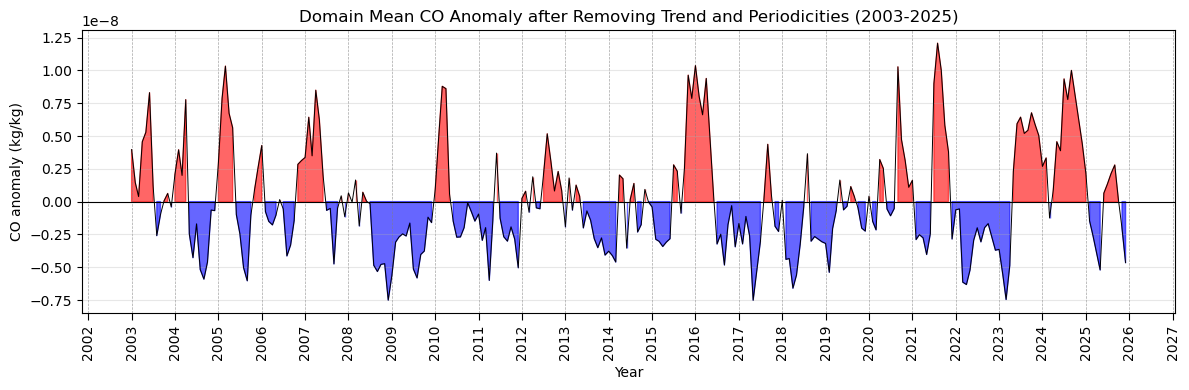

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(ts_anom.time, ts_anom, 0, where=(ts_anom >= 0), color="red", alpha=0.6)
ax.fill_between(ts_anom.time, ts_anom, 0, where=(ts_anom < 0), color="blue", alpha=0.6)
ax.plot(ts_anom.time, ts_anom, color="black", linewidth=0.7)
ax.axhline(0, color="black", linewidth=0.8)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", which="major", length=5, rotation=90)
ax.grid(axis="x", which="major", color="gray", linestyle="--", linewidth=0.5, alpha=0.7)
ax.grid(axis="y", linestyle="-", alpha=0.3)

ax.set_title("Domain Mean CO Anomaly after Removing Trend and Periodicities (2003-2025)")
ax.set_xlabel("Year")
ax.set_ylabel("CO anomaly (kg/kg)")
plt.tight_layout()
plt.show()